<h3> SciPython/Practical_classes_3

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<h4> Gradient Descent Method

### Exercise1

Implement the Gradient Descent method for finding local minima and maxima of the function  
 
$f(w) = -\cos(3w+1) -0.3w^3 +2w$  

Start with initial points $w_0 = -2$ and $w_0 = 1$, and experiment with different values of $\alpha$.  Plot the function $f$ in the range of $w \in <-3,3>$.

<h4> Linear regression model

### Exercise2

 
Consider the following linear model describing the relationship between $Y$ and variables $X_1$, $X_2$:  

$Y = 2X_1 - 3X_2 + 4$

Using this model, answer the following questions:  

- If $X_1 = 10$ and $X_2 = 40$, what is the value of $Y$?  
- If $X_1$ increases by 1 while $X_2$ remains constant, by how much does $Y$ change?  

In [4]:
from sklearn.linear_model import LinearRegression

X = np.array([[1,4],[5,6],[2,2],[6,7],[9,-4],[-2,-3],[-5,1]])
y = np.dot(X, [3, -4])+5+np.random.normal(0,1,7)  #y=3x1-4x2+5+noise

model = LinearRegression()
model.fit(X, y);

In [5]:
model.coef_ #weights for variables

array([ 2.87050768, -3.99716959])

In [6]:
model.intercept_ #w0 parameter

5.341039939696049

In [7]:
r_sq = model.score(X, y) #R2 for model
print(r_sq) 

0.9994454169340113


In [8]:
X_new = np.array([[2,-1],[4,5]])
y_pred = model.predict(X_new) #predictions
print(y_pred)

[15.07922489 -3.16277726]


In [9]:
from sklearn.metrics import mean_squared_error

In [10]:
mean_squared_error(y, model.predict(X))

0.1986023443556883

### Exercise3

Consider the BostonHousing dataset. 

- Split the data into training and test sets (8:2).
- Build a linear model to predict $medv$ using $indus$ and $rm$ as predictors, i.e. $medv = w_1 \cdot indus+w_2 \cdot rm + w_0$.
- Evaluate the model's performance using $MSE$ and $R^2$ on both the training and test sets.
- Create a plot of $Y^p$ versus $Y$ for the test set.
- Finally, analyze and interpret the results - both model parameters (signs) and MSE/R2 measures.

In [11]:
df = pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [12]:
print("""
**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pupil-teacher ratio by town
        - B        1000(Bk - 0.63)^2 where Bk is the proportion of black people by town
        - LSTAT    % lower status of the population
        - MEDV     Median value of owner-occupied homes in $1000's
""")


**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pupil-teacher ratio by town
        - B        1000(Bk - 0.63)^2 where Bk is th

In [13]:
d2 = df[["indus","rm"]] #extract 2 features: INDUS, RM
target = df['medv']

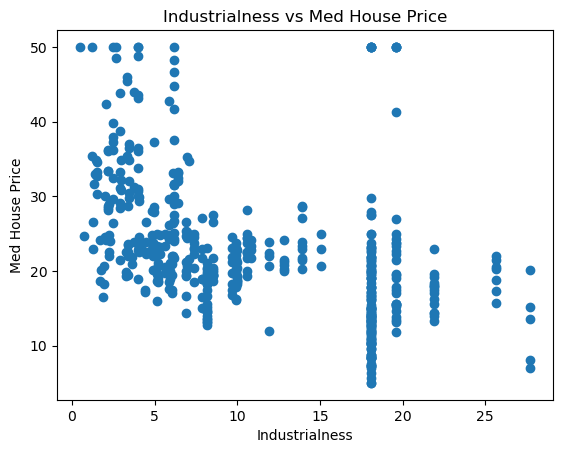

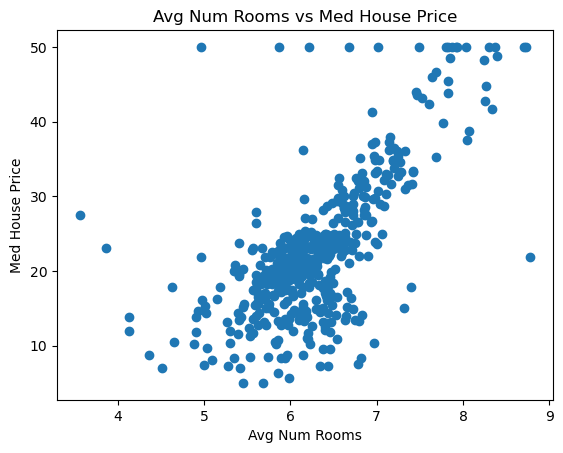

In [14]:
plt.title('Industrialness vs Med House Price')
plt.scatter(d2.iloc[:, 0], target)
plt.xlabel('Industrialness')
plt.ylabel('Med House Price')
plt.show()

plt.title('Avg Num Rooms vs Med House Price')
plt.scatter(d2.iloc[:, 1], target)
plt.xlabel('Avg Num Rooms')
plt.ylabel('Med House Price')
plt.show()

### Exercise4

Consider the BostonHousing dataset once again. 

- Split the data into training and test sets (8:2).
- Add an additional column to the dataframe d2 that is the square of Industrialness,
- Build a model to predict $medv = w_1 \cdot indus+w_2 \cdot rm +w_3 \cdot indus^2 + w_0$
- Evaluate the model's performance using $MSE$ on both the training and test sets.
- Create a plot of $Y^p$ versus $Y$ for the test set.
- Finally, analyze and interpret the results. Compare with previous model, i.e. $medv = w_1 \cdot indus+w_2 \cdot rm + w_0$.

### Exercise5

Cosider the following data. Assume the dependence between $y$ and $x$ can be described by the formula $y = ae^{-bx}$. Transform the model to linear form and calculate parameters $a$ and $b$. Plot both data and model predictions.


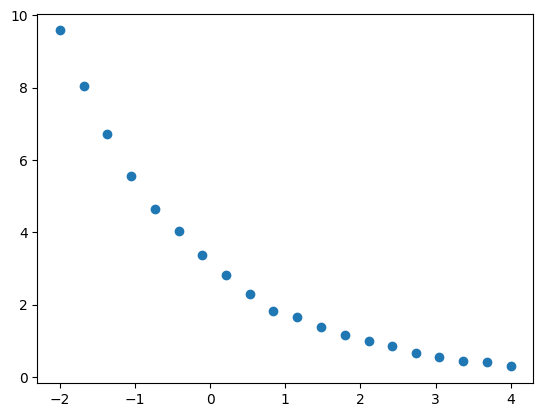

In [23]:
x = np.array([-2.0, -1.68, -1.37, -1.05, -0.74, -0.42, -0.11, 0.21, 0.53, 0.84, 1.16, 1.47, 1.79, 2.11, 2.42, 2.74, 3.05, 3.37, 3.68, 4.0])
y = np.array([9.58, 8.05, 6.71, 5.57, 4.65, 4.03, 3.36, 2.81, 2.3, 1.83, 1.65, 1.37, 1.15, 0.99, 0.86, 0.65, 0.54, 0.43, 0.4, 0.29])

plt.scatter(x,y)
plt.show()

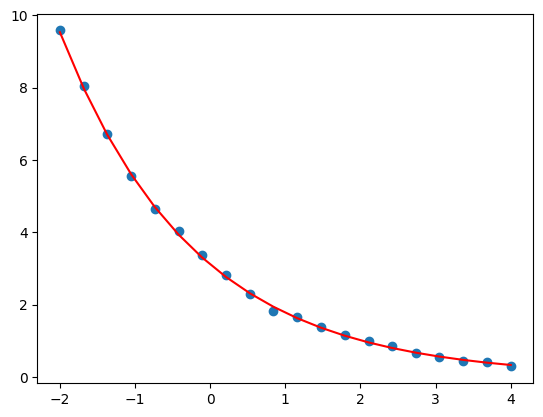

In [35]:
#Expectations

<h3> Supplementary materials

* Functions on vectors

In [114]:
x = np.array([1,2,3,4])
print(np.sin(x))
print()
print(np.log(x))
print()
print(np.exp(x))

[ 0.84147098  0.90929743  0.14112001 -0.7568025 ]

[0.         0.69314718 1.09861229 1.38629436]

[ 2.71828183  7.3890561  20.08553692 54.59815003]


* Vectors into matrices


In [82]:
x = np.array([1,2,3,4])
print(x.reshape(2,2))
print()
print(x.reshape(-1,1))

[[1 2]
 [3 4]]

[[1]
 [2]
 [3]
 [4]]


In [22]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.vstack((a,b)))
print()
print(np.transpose(np.vstack((a,b))))

[[1 2 3]
 [4 5 6]]

[[1 4]
 [2 5]
 [3 6]]


* DataFrames

In [3]:
import pandas as pd

df = pd.DataFrame({"a":[1,2.5,3], "b":[4,5,6]})
print(df)

     a  b
0  1.0  4
1  2.5  5
2  3.0  6


In [4]:
df["a"]

0    1.0
1    2.5
2    3.0
Name: a, dtype: float64

In [5]:
df["c"] = df["a"]**2
print(df)

     a  b     c
0  1.0  4  1.00
1  2.5  5  6.25
2  3.0  6  9.00


* Find the minimum falue of $f(w_1,w_2) = (w_1-1)^2+(w_2+3)^2$

In [2]:
from scipy.optimize import minimize #in-built method for minimization

fun = lambda w: (w[0] - 1)**2 + (w[1] + 3)**2
res = minimize(fun, (2, 0), method='SLSQP')
print(res.x) #where is the minimum?

[ 1. -3.]


In [3]:
fun([1,-3])

0